In [27]:
import os
import json

import geopandas as gpd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
color_sheet = pd.read_excel('CGMW_ICS_colour_codes.xlsx',skiprows=9)
header = pd.read_excel('CGMW_ICS_colour_codes.xlsx',header=5).columns
color_sheet.columns = header

color_dict = dict(zip(color_sheet['Long List (formatted)'],color_sheet['HTML RGB HASH']))
color_dict[None] = '#FFFFFF'
print(color_dict)

{'Upper/Late Holocene': '#FDEDEC', 'Northgrippian': '#FDECE4', 'Middle Holocene': '#FDECE4', 'Greenlandian': '#FEECDB', 'Lower/Early Holocene': '#FEECDB', 'Holocene': '#FEEBD2', 'Upper Pleistocene': '#FFF2D3', 'Upper/Late Pleistocene': '#FFF2D3', 'Chibanian': '#FFF2C7', 'Middle Pleistocene': '#FFF2C7', 'Calabrian': '#FFF2BA', 'Gelasian': '#FFEDB3', 'Lower/Early Pleistocene': '#FFF0B9', 'Pleistocene': '#FFEFAF', 'Quaternary': '#F9F97F', 'Piacenzian': '#FFFFBF', 'Upper/Late Pliocene': '#FFF2CD', 'Zanclean': '#FFFFB3', 'Lower/Early Pliocene': '#FFF2C3', 'Pliocene': '#FFFF99', 'Messinian': '#FFFF73', 'Tortonian': '#FFFF66', 'Upper/Late Miocene': '#FFEC8C', 'Serravallian': '#FFFF59', 'Langhian': '#FFFF4D', 'Middle Miocene': '#FFEC73', 'Burdigalian': '#FFFF41', 'Aquitanian': '#FFFF33', 'Lower/Early Miocene': '#FFEC55', 'Miocene': '#FFFF00', 'Neogene': '#FFE619', 'Chattian': '#FEE6AA', 'Rupelian': '#FED99A', 'Oligocene': '#FEC07A', 'Priabonian': '#FDCDA1', 'Bartonian': '#FDC091', 'Lutetian': 

In [29]:
with open('color_dict.json','w') as f:
    json.dump(color_dict,f)

In [30]:
# Read file from local directory
local_map_dir = '/mnt/box/internal_files/gis/geologic_maps/morocco/tectonicmap'
filename = os.path.join(local_map_dir,'morocco_tectonic_map.gpkg')
tect_map = gpd.read_file(filename,layer='polygons_base')

In [31]:
map_units = tect_map.label.unique()
map_units.sort()
print(map_units)

unit_colors = {}

['ag-es_basin' 'anti_atlas' 'cz_basin' 'cz_plateau' 'cz_rif' 'j_east'
 'j_highatlas' 'j_middleatlas' 'j_oujda' 'k_basin' 'meseta' 'mz_rif'
 'pz_east' 'pz_highatlas' 'pz_middleatlas' 'pz_south' 'q_magma' 'tr']


In [32]:
# Write function for generating colors
def generate_colors(units,age_base):
    color_base = color_dict[age_base]
    n_colors = len(units)
    n_halved = int(n_colors/2)+2

    colors_dark = sns.dark_palette(color_base,n_colors=n_halved).as_hex()
    colors_light = sns.light_palette(color_base,n_colors=n_halved).as_hex()
    colors_light.reverse()
    colors= colors_dark + colors_light[1:]

    sns.palplot(colors)
    return colors

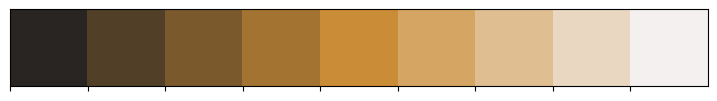

In [33]:
# Precambrian/Paleozoic (6)
pz_units = ['anti_atlas','meseta','pz_east','pz_highatlas','pz_middleatlas','pz_south']
colors = generate_colors(pz_units,'Devonian')

unit_colors.update({'anti_atlas':colors[4],'meseta':colors[5],'pz_east':colors[3],
 'pz_highatlas':colors[6],'pz_middleatlas':colors[7],'pz_south':colors[2]}) 

In [34]:
# Triassic (1)
unit_colors.update({'tr':color_dict['Triassic']})

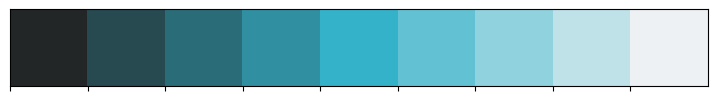

In [35]:
# Jurassic (6)
j_units = ['ag-es_basin','j_east','j_highatlas','j_middleatlas','j_oujda','mz_rif']
colors = generate_colors(j_units,'Jurassic')

unit_colors.update({'ag-es_basin':colors[4],'j_east':colors[5],'j_highatlas':colors[3],
 'j_middleatlas':colors[6],'j_oujda':colors[7],'mz_rif':colors[2]}) 


In [36]:
# Cretaceous (1)
unit_colors.update({'k_basin':color_dict['Cretaceous']})

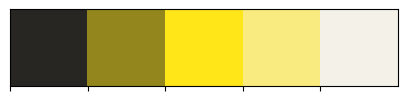

In [37]:
# Early Cenozoic 
ecz_units = ['cz_plateau','cz_rif']
colors = generate_colors(ecz_units,'Neogene')

unit_colors.update({'cz_plateau':colors[2],'cz_rif':colors[3]}) 

In [38]:
# Late Cenozoic
unit_colors.update({'cz_basin':color_dict['Quaternary']})
unit_colors.update({'q_magma':'red'})

In [39]:
tect_map['unit_color'] = tect_map['label'].map(unit_colors)
tect_map.to_file(filename,layer='polygons_colored',overwrite=True)